# Stage 5: Feature Engineering & Selection

---

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('./data/processed/water_potability_cleaned.csv')
feature_cols = [c for c in df.columns if c != 'Potability']
X = df[feature_cols]
y = df['Potability']
print(f'Features: {list(feature_cols)}')

Features: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']


## 5.1 Domain-Driven Feature Engineering

We create new features based on WHO guidelines and domain knowledge about water chemistry.

In [8]:
df_eng = df.copy()

# --- WHO Safety Flags ---
# Binary flags: 1 = within WHO safe limit, 0 = outside
df_eng['ph_safe']            = ((df['ph'] >= 6.5) & (df['ph'] <= 8.5)).astype(int)
df_eng['hardness_safe']      = (df['Hardness'] < 300).astype(int)
df_eng['solids_safe'] = (df['Solids'] < 1000).astype(int)
df_eng['chloramines_safe']   = (df['Chloramines'] < 4).astype(int)
df_eng['sulfate_safe']       = (df['Sulfate'] < 250).astype(int)
df_eng['conductivity_safe']  = (df['Conductivity'] < 400).astype(int)
df_eng['organic_carbon_safe']= (df['Organic_carbon'] < 2).astype(int)
df_eng['thm_safe']           = (df['Trihalomethanes'] < 80).astype(int)
df_eng['turbidity_safe']     = (df['Turbidity'] < 5).astype(int)

# Composite: total number of parameters within WHO limits (0-9)
safe_cols = [c for c in df_eng.columns if c.endswith('_safe')]
df_eng['total_who_compliant'] = df_eng[safe_cols].sum(axis=1)

# --- Ratio Features ---
df_eng['hardness_to_conductivity'] = df['Hardness'] / (df['Conductivity'] + 1e-6)
df_eng['chloramines_to_thm']       = df['Chloramines'] / (df['Trihalomethanes'] + 1e-6)
df_eng['organic_to_turbidity']     = df['Organic_carbon'] / (df['Turbidity'] + 1e-6)

# --- pH Deviation from neutral (7.0) ---
df_eng['ph_deviation']             = abs(df['ph'] - 7.0)

# --- Log transforms for skewed features ---
df_eng['log_solids']               = np.log1p(df['Solids'])
df_eng['log_conductivity']         = np.log1p(df['Conductivity'])

new_features = [c for c in df_eng.columns if c not in list(df.columns)]
print(f'New features created ({len(new_features)}):')
for f in new_features:
    print(f'  • {f}')

New features created (16):
  • ph_safe
  • hardness_safe
  • solids_safe
  • chloramines_safe
  • sulfate_safe
  • conductivity_safe
  • organic_carbon_safe
  • thm_safe
  • turbidity_safe
  • total_who_compliant
  • hardness_to_conductivity
  • chloramines_to_thm
  • organic_to_turbidity
  • ph_deviation
  • log_solids
  • log_conductivity


## 5.2 Feature Importance — Random Forest

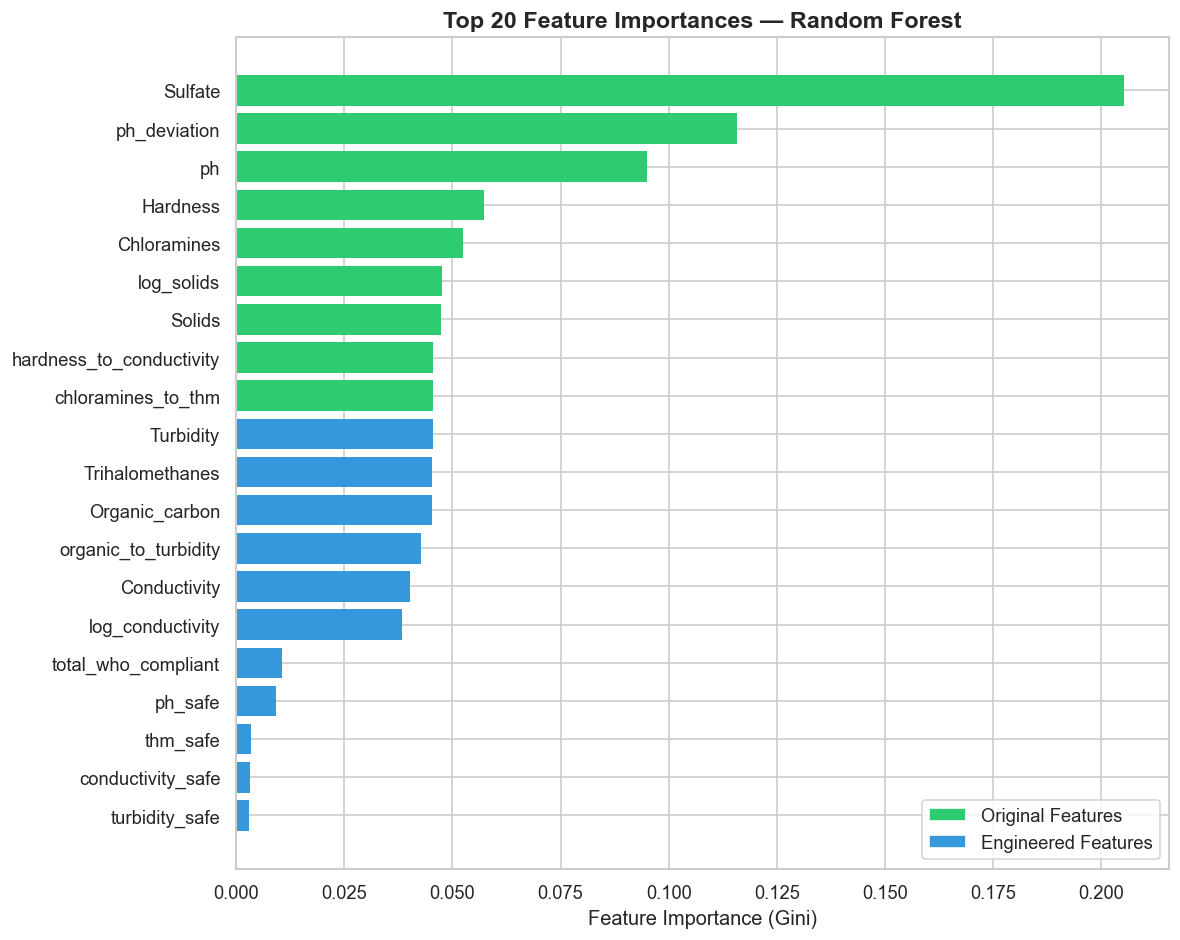

In [9]:
all_features = [c for c in df_eng.columns if c != 'Potability']
X_eng = df_eng[all_features]
y = df_eng['Potability']

# Quick RF for importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_eng, y)

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 20
top20 = importance_df.head(20)
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71' if i < 9 else '#3498db' for i in range(len(top20))]
ax.barh(top20['Feature'][::-1], top20['Importance'][::-1], color=colors[::-1], edgecolor='none')
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Original Features'),
                   Patch(facecolor='#3498db', label='Engineered Features')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('./data/processed/feature_importance_rf.png', bbox_inches='tight', dpi=150)
plt.show()

## 5.3 Mutual Information Scores

C:\Users\BAINTY KAUR\AppData\Local\Temp\ipykernel_14128\2775663205.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df.head(20), y='Feature', x='MI Score',


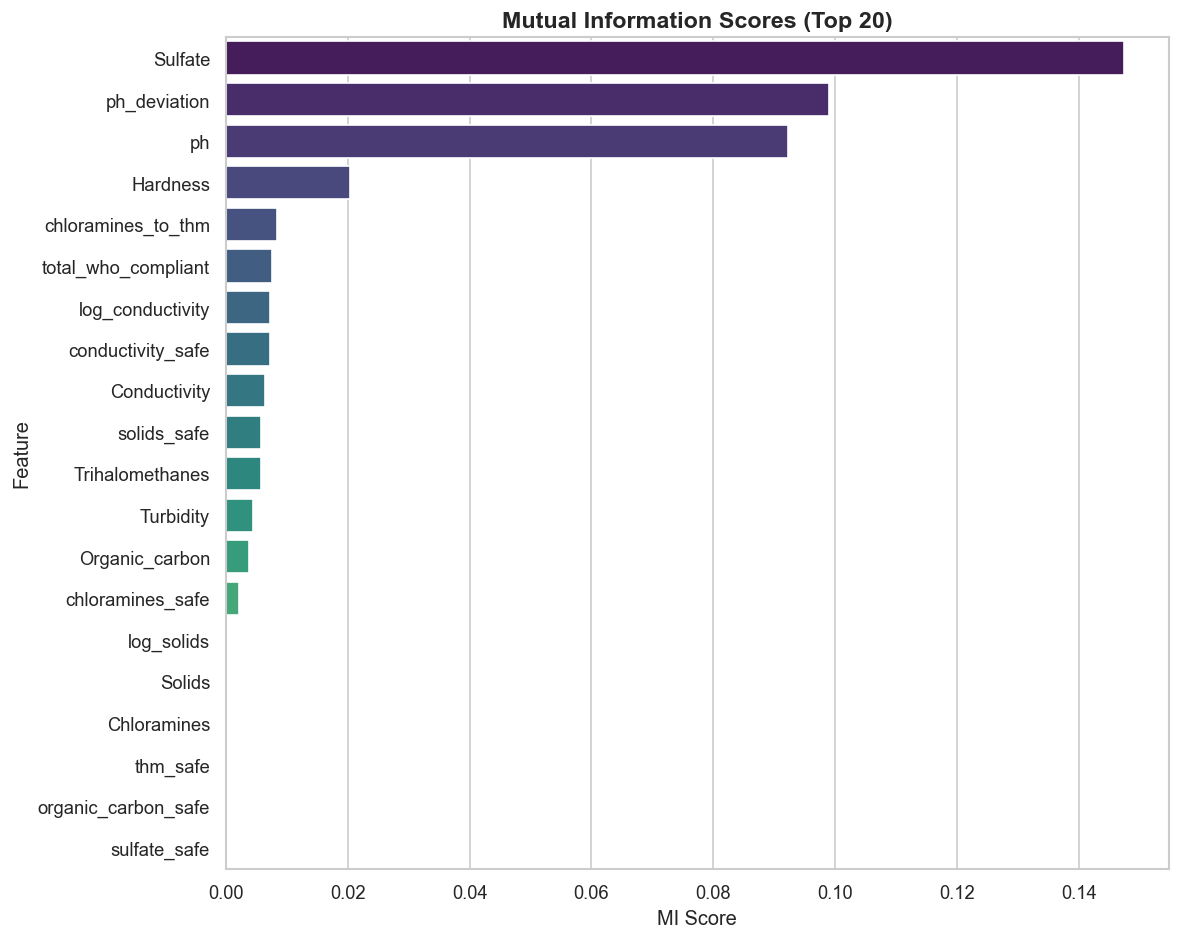

In [10]:
mi_scores = mutual_info_classif(X_eng, y, random_state=42)
mi_df = pd.DataFrame({'Feature': all_features, 'MI Score': mi_scores})\
           .sort_values('MI Score', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=mi_df.head(20), y='Feature', x='MI Score', 
            palette='viridis', orient='h')
plt.title('Mutual Information Scores (Top 20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/mutual_information.png', bbox_inches='tight', dpi=150)
plt.show()

## 5.4 Feature Selection — Keep Top Features + Engineered

In [11]:
# Select: all original + top engineered features
# Use features with RF importance > 0.01
selected_features = importance_df[importance_df['Importance'] > 0.01]['Feature'].tolist()
print(f'Selected {len(selected_features)} features (importance > 0.01):')
for f in selected_features:
    print(f'  • {f}  ({importance_df[importance_df["Feature"]==f]["Importance"].values[0]:.4f})')

Selected 16 features (importance > 0.01):
  • Sulfate  (0.2053)
  • ph_deviation  (0.1159)
  • ph  (0.0949)
  • Hardness  (0.0573)
  • Chloramines  (0.0525)
  • log_solids  (0.0476)
  • Solids  (0.0473)
  • hardness_to_conductivity  (0.0455)
  • chloramines_to_thm  (0.0454)
  • Turbidity  (0.0454)
  • Trihalomethanes  (0.0453)
  • Organic_carbon  (0.0453)
  • organic_to_turbidity  (0.0427)
  • Conductivity  (0.0403)
  • log_conductivity  (0.0384)
  • total_who_compliant  (0.0106)


## 5.5 Feature Scaling

In [12]:
from sklearn.model_selection import train_test_split

X_selected = df_eng[selected_features]
y = df_eng['Potability']

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (required for SVM)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=selected_features)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=selected_features)

print(f'Train set: {X_train.shape} | Test set: {X_test.shape}')
print(f'Train class dist: {dict(y_train.value_counts())}')
print(f'Test class dist:  {dict(y_test.value_counts())}')

# Save artifacts
joblib.dump(scaler, './models/scaler.pkl')
joblib.dump(selected_features, './models/selected_features.pkl')

# Save engineered dataset
df_eng[selected_features + ['Potability']].to_csv(
    './data/processed/water_potability_engineered.csv', index=False
)

# Save split data
X_train.to_csv('./data/processed/X_train.csv', index=False)
X_test.to_csv('./data/processed/X_test.csv', index=False)
y_train.to_csv('./data/processed/y_train.csv', index=False)
y_test.to_csv('./data/processed/y_test.csv', index=False)
X_train_scaled.to_csv('./data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('./data/processed/X_test_scaled.csv', index=False)

print('\n✓ All artifacts saved to models/ and data/processed/')

Train set: (2620, 16) | Test set: (656, 16)
Train class dist: {0: np.int64(1598), 1: np.int64(1022)}
Test class dist:  {0: np.int64(400), 1: np.int64(256)}

✓ All artifacts saved to models/ and data/processed/
